In [1]:
!pip install timm
!pip install albumentations
!pip install torchinfo

In [2]:
# ==========================================================
# Imports & Reproducibility
# ==========================================================

import os
import cv2
import timm
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

C:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.11.0+cpu
CUDA available: False


In [3]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Active Device:", device)

Active Device: cpu


In [4]:
# ==========================================================
# Dataset Paths
# ==========================================================

BASE_DIR = r"C:\Users\ASUS\OneDrive\Documents\licenta\RetinaXAI\data\aptos2019-blindness-detection"

train_dir = os.path.join(BASE_DIR, "train_images")
test_dir = os.path.join(BASE_DIR, "test_images")

print("Training Folder path:", train_dir)
print("Testing Folder path :", test_dir)

# ==========================================================
# Load CSV Files
# ==========================================================

train_csv = os.path.join(BASE_DIR, "train.csv")
test_csv = os.path.join(BASE_DIR, "test.csv")

train = pd.read_csv(train_csv)
test = pd.read_csv(test_csv)

print(train.head())
print(test.head())

Training Folder path: C:\Users\ASUS\OneDrive\Documents\licenta\RetinaXAI\data\aptos2019-blindness-detection\train_images
Testing Folder path : C:\Users\ASUS\OneDrive\Documents\licenta\RetinaXAI\data\aptos2019-blindness-detection\test_images
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
        id_code
0  0005cfc8afb6
1  003f0afdcd15
2  006efc72b638
3  00836aaacf06
4  009245722fa4


diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


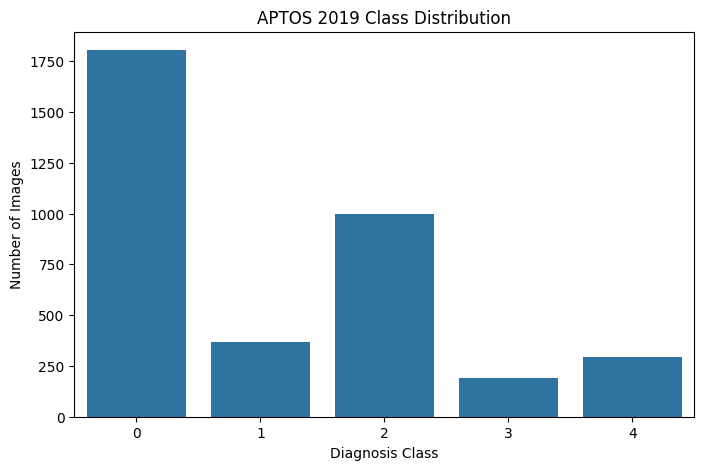

In [5]:
# ==========================================================
# Class Distribution
# ==========================================================

print(train["diagnosis"].value_counts())

plt.figure(figsize=(8, 5))

sns.countplot(x=train["diagnosis"])

plt.title("APTOS 2019 Class Distribution")
plt.xlabel("Diagnosis Class")
plt.ylabel("Number of Images")

plt.show()

In [6]:
# ==========================================================
# Stratified Train / Validation Split
# ==========================================================

train_df, val_df = train_test_split(
    train,
    test_size=0.25,
    stratify=train["diagnosis"],
    random_state=SEED
)

print("Train set distribution:")
print(train_df["diagnosis"].value_counts())

print("\nValidation set distribution:")
print(val_df["diagnosis"].value_counts())

Train set distribution:
diagnosis
0    1354
2     749
1     277
4     221
3     145
Name: count, dtype: int64

Validation set distribution:
diagnosis
0    451
2    250
1     93
4     74
3     48
Name: count, dtype: int64


In [7]:
# ==========================================================
# Dataset Class
# ==========================================================

class FundusDataset(Dataset):
    def __init__(self, dataframe, image_folder, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.loc[idx, "id_code"] + ".png"
        img_path = os.path.join(self.image_folder, img_name)

        image = cv2.imread(img_path)

        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label = int(self.dataframe.loc[idx, "diagnosis"])

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, label

In [8]:
# ==========================================================
# Image Transformations / Augmentation
# ==========================================================

import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 512

train_transforms = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.RandomBrightnessContrast(p=0.2),
    A.Blur(blur_limit=3, p=0.3),
    A.HorizontalFlip(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

In [ ]:
# ==========================================================
# Create Datasets and DataLoaders
# ==========================================================        

BATCH_SIZE = 16

train_dataset = FundusDataset(
    dataframe=train_df,
    image_folder=train_dir,
    transform=train_transforms
)

val_dataset = FundusDataset(
    dataframe=val_df,
    image_folder=train_dir,
    transform=val_transforms
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Check one batch
images, labels = next(iter(train_dataloader))

print(f"Image shape: {images.shape}")
print(f"Label shape: {labels.shape}")
print(f"Labels example: {labels[:10]}")

Image shape: torch.Size([16, 3, 512, 512])
Label shape: torch.Size([16])
Labels example: tensor([0, 3, 0, 2, 2, 1, 2, 2, 0, 2])


In [10]:
# ==========================================================
# Build EfficientNetB0 Model
# ==========================================================

model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=5
)

model = model.to(device)

print(model)

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [11]:
# ==========================================================
# Loss Function and Optimizer
# ==========================================================

error = nn.CrossEntropyLoss()

learning_rate = 1e-4

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

In [12]:
# ==========================================================
# Training + Validation Loop
# ==========================================================

epochs = 10

best_val_loss = float("inf")

for epoch in range(epochs):

    # ---------------- TRAIN ----------------
    model.train()

    train_loss_total = 0.0
    train_correct = 0
    train_samples = 0

    for image, label in train_dataloader:

        image = image.to(device).float()
        label = label.to(device)

        optimizer.zero_grad()

        outputs = model(image)

        loss = error(outputs, label)

        loss.backward()
        optimizer.step()

        train_loss_total += loss.item() * image.size(0)

        predicted = torch.argmax(outputs, dim=1)

        train_samples += label.size(0)
        train_correct += (predicted == label).sum().item()

    train_loss = train_loss_total / train_samples
    train_accuracy = train_correct / train_samples

    # ---------------- VALIDATION ----------------
    model.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_samples = 0

    with torch.no_grad():

        for image, label in val_dataloader:

            image = image.to(device).float()
            label = label.to(device)

            outputs = model(image)

            loss = error(outputs, label)

            val_loss_total += loss.item() * image.size(0)

            predicted = torch.argmax(outputs, dim=1)

            val_samples += label.size(0)
            val_correct += (predicted == label).sum().item()

    validation_loss = val_loss_total / val_samples
    validation_accuracy = val_correct / val_samples

    # ---------------- SAVE BEST MODEL ----------------
    if validation_loss < best_val_loss:

        best_val_loss = validation_loss

        torch.save(
            model.state_dict(),
            "best_model_effnetb0_severity.pth"
        )

        print("Best model saved.")

    # ---------------- EPOCH RESULTS ----------------
    print(f"\nEpoch {epoch+1}/{epochs}")

    print(
        "Train Accuracy     : {:.2f}%".format(
            train_accuracy * 100
        )
    )

    print(
        "Validation Accuracy: {:.2f}%".format(
            validation_accuracy * 100
        )
    )

    print(
        "Train Loss         : {:.4f}".format(
            train_loss
        )
    )

    print(
        "Validation Loss    : {:.4f}".format(
            validation_loss
        )
    )

Best model saved.

Epoch 1/10
Train Accuracy     : 72.21%
Validation Accuracy: 75.98%
Train Loss         : 0.8313
Validation Loss    : 0.6488
Best model saved.

Epoch 2/10
Train Accuracy     : 84.05%
Validation Accuracy: 78.82%
Train Loss         : 0.4343
Validation Loss    : 0.5974
Best model saved.

Epoch 3/10
Train Accuracy     : 88.13%
Validation Accuracy: 81.00%
Train Loss         : 0.3189
Validation Loss    : 0.5809

Epoch 4/10
Train Accuracy     : 90.86%
Validation Accuracy: 81.66%
Train Loss         : 0.2564
Validation Loss    : 0.6290

Epoch 5/10
Train Accuracy     : 93.74%
Validation Accuracy: 82.21%
Train Loss         : 0.1869
Validation Loss    : 0.6553

Epoch 6/10
Train Accuracy     : 95.70%
Validation Accuracy: 80.68%
Train Loss         : 0.1376
Validation Loss    : 0.6770

Epoch 7/10
Train Accuracy     : 96.03%
Validation Accuracy: 80.90%
Train Loss         : 0.1352
Validation Loss    : 0.6550

Epoch 8/10
Train Accuracy     : 97.45%
Validation Accuracy: 81.66%
Train Loss

Final Validation Accuracy: 0.8100436681222707

Classification Report:
                  precision    recall  f1-score   support

           No DR     0.9665    0.9601    0.9633       451
            Mild     0.5904    0.5269    0.5568        93
        Moderate     0.7061    0.8360    0.7656       250
          Severe     0.4651    0.4167    0.4396        48
Proliferative DR     0.6739    0.4189    0.5167        74

        accuracy                         0.8100       916
       macro avg     0.6804    0.6317    0.6484       916
    weighted avg     0.8073    0.8100    0.8045       916



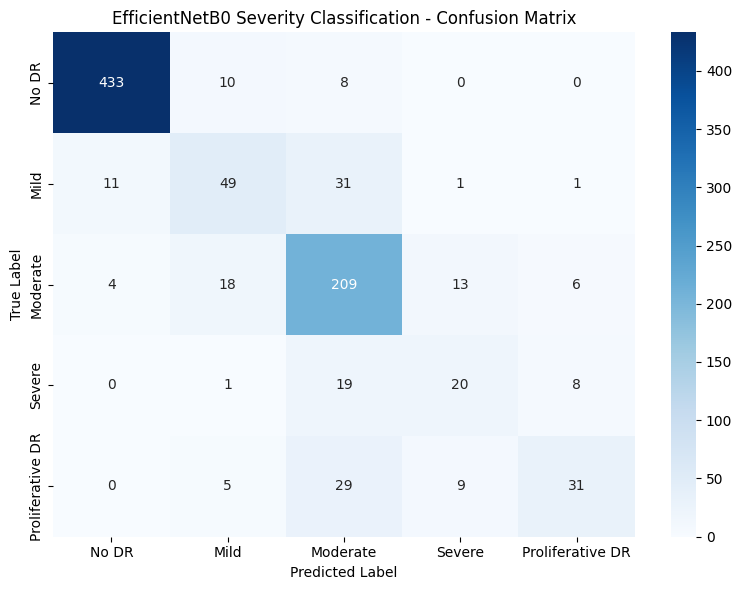

In [15]:
# ==========================================================
# Final Evaluation: Classification Report + Confusion Matrix
# ==========================================================

import os
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np

os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/confusion_matrices", exist_ok=True)
os.makedirs("outputs/classification_reports", exist_ok=True)

# Load best saved EfficientNetB0 model
model.load_state_dict(torch.load("best_model_effnetb0_severity.pth", map_location=device))
model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_dataloader:
        images = images.to(device).float()
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)

print("Final Validation Accuracy:", accuracy)

class_names = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:")
print(report)

with open("outputs/classification_reports/efficientnetb0_severity_report.txt", "w") as f:
    f.write(f"Final Validation Accuracy: {accuracy}\n\n")
    f.write(report)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EfficientNetB0 Severity Classification - Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/confusion_matrices/efficientnetb0_severity_confusion_matrix.png", dpi=300)
plt.show()

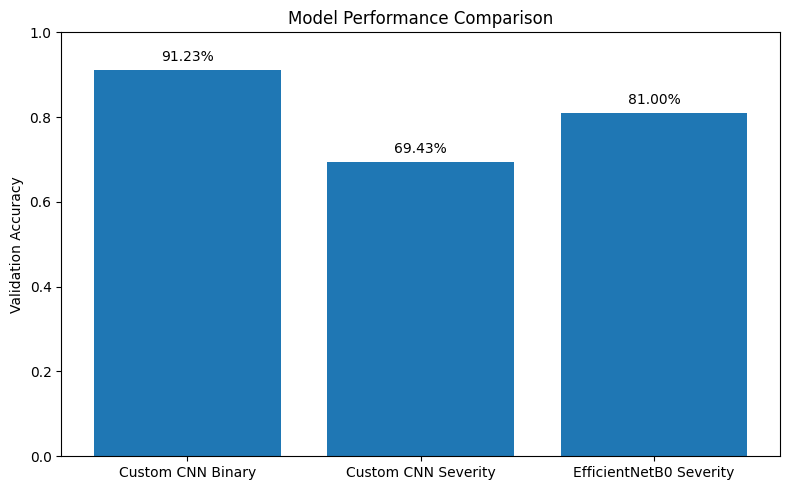

In [16]:
import matplotlib.pyplot as plt
import os

os.makedirs("outputs/plots", exist_ok=True)

models = ["Custom CNN Binary", "Custom CNN Severity", "EfficientNetB0 Severity"]

val_acc = [0.9123, 0.6943, 0.81]

plt.figure(figsize=(8, 5))
plt.bar(models, val_acc)

plt.ylabel("Validation Accuracy")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)

for i, value in enumerate(val_acc):
    plt.text(i, value + 0.02, f"{value:.2%}", ha="center")

plt.tight_layout()
plt.savefig("outputs/plots/model_performance_comparison.png", dpi=300)
plt.show()

In [18]:
import pandas as pd
import os

os.makedirs("outputs/tables", exist_ok=True)

comparison_table = {
    "Model": [
        "Custom CNN",
        "Custom CNN",
        "EfficientNetB0"
    ],
    "Task": [
        "Binary classification",
        "Severity classification",
        "Severity classification"
    ],
    "Number of classes": [
        2,
        5,
        5
    ],
    "Validation Accuracy": [
        0.9123,
        0.6943,
        0.81
    ],
    "Notes": [
        "Baseline model with good binary performance",
        "Struggled with minority severity classes",
        "Transfer learning model selected for final severity classification"
    ]
}

df_comparison = pd.DataFrame(comparison_table)

df_comparison.to_csv("outputs/tables/model_comparison.csv", index=False)

df_comparison

,Model,Task,Number of classes,Validation Accuracy,Notes
0,Custom CNN,Binary classification,2,0.9123,Baseline model with good binary performance
1,Custom CNN,Severity classification,5,0.6943,Struggled with minority severity classes
2,EfficientNetB0,Severity classification,5,0.8100,Transfer learning model selected for final sev...


In [19]:
# ==========================================================
# Grad-CAM for EfficientNetB0
# ==========================================================

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        score = output[:, class_idx]
        score.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam = cam.cpu().numpy()

        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam, class_idx

In [20]:
# Last convolutional layer for EfficientNetB0
target_layer = model.conv_head

gradcam = GradCAM(model, target_layer)

Selected indices: {0: 0, 4: 5, 2: 6, 1: 13, 3: 51}


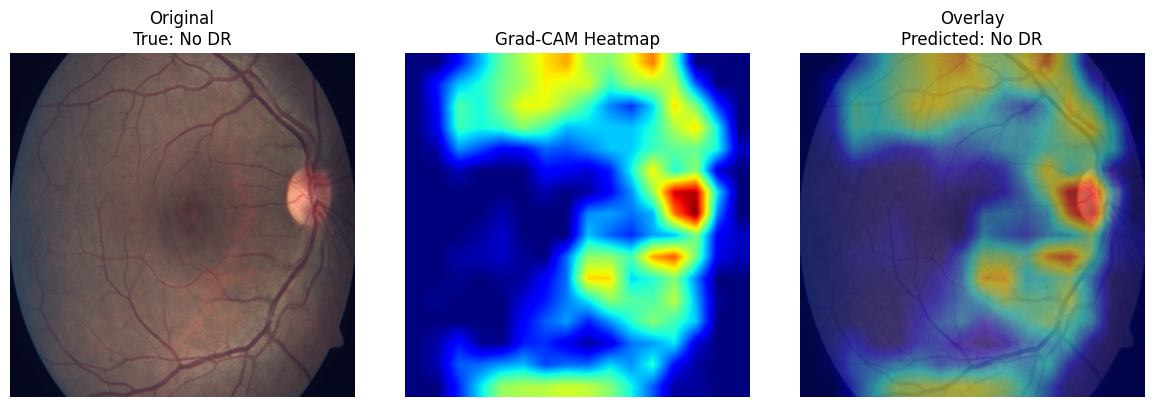

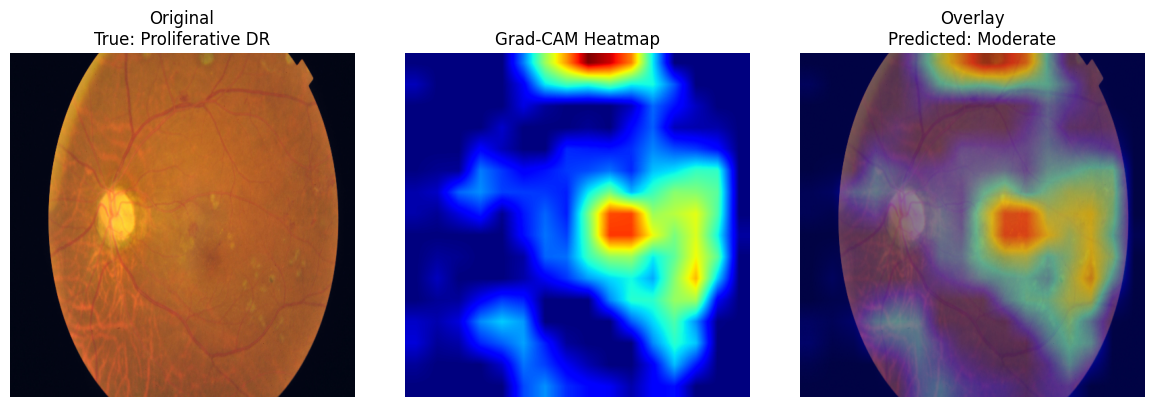

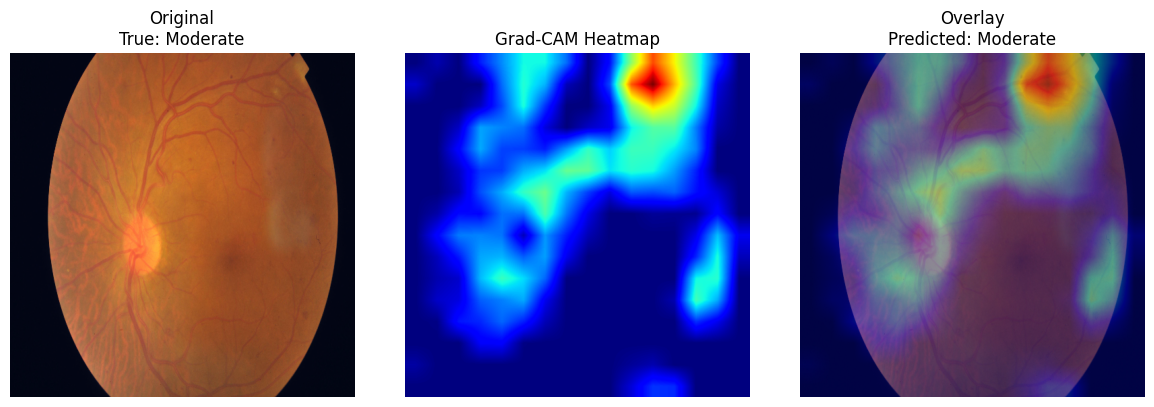

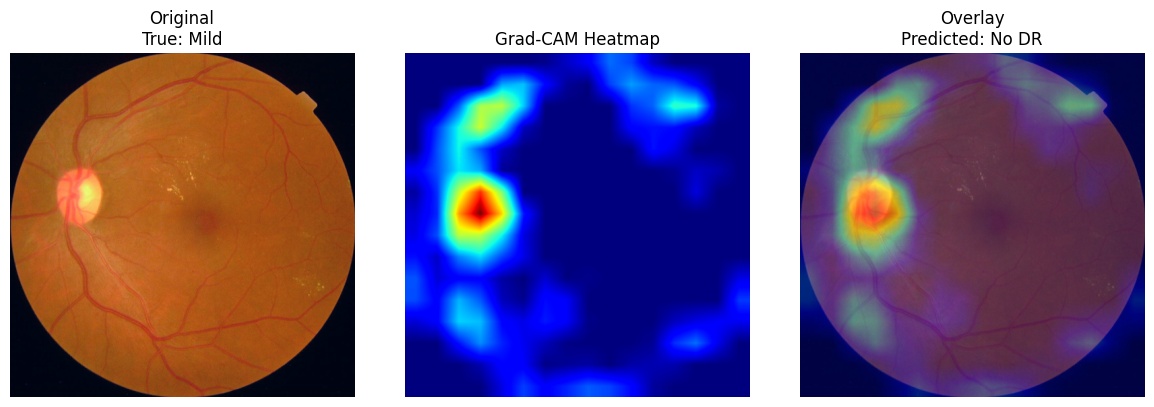

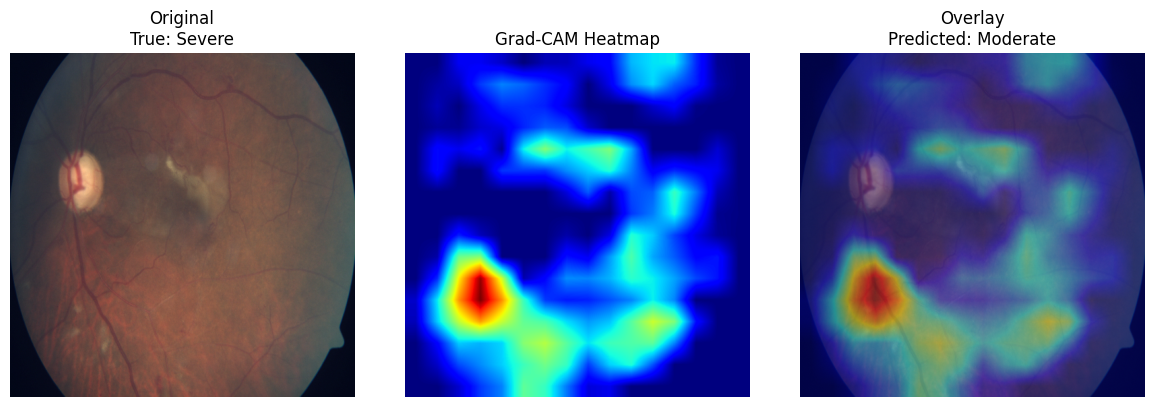

In [22]:
# ==========================================================
# Generate Grad-CAM Examples for Each Severity Class
# ==========================================================

os.makedirs("outputs/heatmaps/by_class", exist_ok=True)

selected_indices = {}

# Find one validation image per class
for idx in range(len(val_dataset)):
    _, label = val_dataset[idx]

    if label not in selected_indices:
        selected_indices[label] = idx

    if len(selected_indices) == 5:
        break

print("Selected indices:", selected_indices)

for true_label, idx in selected_indices.items():
    image_tensor, true_label = val_dataset[idx]

    input_tensor = image_tensor.unsqueeze(0).to(device).float()

    cam, predicted_class = gradcam.generate(input_tensor)

    img = image_tensor.permute(1, 2, 0).cpu().numpy()
    img = img - img.min()
    img = img / (img.max() + 1e-8)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = heatmap.astype(np.float32) / 255.0

    overlay = 0.55 * img + 0.45 * heatmap
    overlay = np.clip(overlay, 0, 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Original\nTrue: {class_names[true_label]}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"Overlay\nPredicted: {class_names[predicted_class]}")
    plt.axis("off")

    plt.tight_layout()

    save_path = f"outputs/heatmaps/by_class/gradcam_true_{class_names[true_label].replace(' ', '_')}_pred_{class_names[predicted_class].replace(' ', '_')}.png"
    plt.savefig(save_path, dpi=300)
    plt.show()